In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("C:\\Users\\ME\\Desktop\\AI_projects\\Hospital_data.xlsx")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 527 entries, 0 to 526
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   ID                               527 non-null    int64         
 1   Department                       527 non-null    object        
 2   Birth place                      527 non-null    object        
 3   Discharge diagnosis              527 non-null    object        
 4   Other diagnoses for discharge    527 non-null    object        
 5   Admission time                   527 non-null    datetime64[ns]
 6   Discharge time                   527 non-null    datetime64[ns]
 7   days                             523 non-null    float64       
 8   fees                             527 non-null    float64       
 9   outpatient physician             527 non-null    object        
 10  Outpatient physician department  527 non-null    object       

In [4]:
df.describe()

,ID,Admission time,Discharge time,days,fees,lab fees,Inspection fees,Western medicine fees,Nursing fee,grass fee,Anesthesia fee,Other fees,Surgery Fees,bed fee,Medical fees
count,527.000000,527,527,523.000000,527.000000,527.000000,527.000000,527.000000,527.000000,527.000000,527.000000,527.000000,527.000000,527.000000,527.000000
mean,264.000000,2016-02-01 01:08:18.671726848,2016-02-14 17:53:51.119544576,13.703633,3203.994061,518.262581,268.302657,1117.079753,66.246679,5.834080,83.107400,229.627704,189.229602,94.049526,511.581973
min,1.000000,2015-04-07 00:00:00,2016-02-01 00:00:00,0.000000,396.180000,23.500000,0.000000,0.000000,0.000000,0.000000,0.000000,5.500000,0.000000,0.000000,0.000000
25%,132.500000,2016-01-25 00:00:00,2016-02-05 00:00:00,6.000000,1847.150000,385.000000,40.000000,229.640000,28.000000,0.000000,0.000000,77.650000,0.000000,50.400000,140.500000
50%,264.000000,2016-02-02 00:00:00,2016-02-16 00:00:00,10.000000,2615.310000,483.500000,175.000000,785.040000,42.000000,0.000000,0.000000,113.800000,0.000000,75.600000,287.500000
75%,395.500000,2016-02-14 00:00:00,2016-02-23 00:00:00,16.000000,3823.715000,563.750000,403.000000,1809.805000,68.000000,0.000000,45.000000,203.375000,360.000000,113.400000,556.750000
max,527.000000,2016-02-27 00:00:00,2016-02-28 00:00:00,317.000000,23503.400000,2239.500000,2012.000000,7258.850000,969.000000,396.000000,909.000000,15560.520000,3470.000000,527.400000,9415.000000
std,152.276065,NaN,NaN,20.039476,2423.879827,236.529543,276.032340,1116.589878,89.464630,27.123946,166.146674,932.162046,366.724037,70.152983,878.490769


In [5]:
# Formatting datetime from String to datetime object

df['Admission time'] = pd.to_datetime(df['Admission time'], errors='coerce')
df['Discharge time'] = pd.to_datetime(df['Discharge time'], errors='coerce')

Changing column names to lower case and to a consistent naming style

In [6]:

df.columns = df.columns.str.strip().str.lower()

In [7]:
df.columns = df.columns.str.strip().str.replace(' ', '_')

In [8]:
df

,id,department,birth_place,discharge_diagnosis,other_diagnoses_for_discharge,admission_time,discharge_time,days,fees,outpatient_physician,...,lab_fees,inspection_fees,western_medicine_fees,nursing_fee,grass_fee,anesthesia_fee,other_fees,surgery_fees,bed_fee,medical_fees
0,1,"Department of Obstetrics and Gynecology, Weste...",Guizhou,G1P1 LSA cesarean section at 38 weeks gestation,Breech presentation,2016-02-04,2016-02-23,NaN,2825.32,Korea**,...,579.5,30.0,227.24,108,0.00,406.0,346.48,500,63.6,556.0
1,2,"Department of Obstetrics and Gynecology, Sout...","Anshun, Guizhou",G4P1 Mid-term induction of labor at 24+6 week...,Mild anemia during pregnancy,2016-02-15,2016-02-19,NaN,2163.08,Gu**,...,499.0,120.0,50.00,42,0.00,15.0,645.68,470,54.4,266.5
2,3,Internal Medicine,"Anshun, Guizhou",type 2 diabetes,reactive hypoglycemia,2016-01-25,2016-02-17,NaN,1649.48,Yin**,...,539.5,176.0,339.58,42,0.00,0.0,243.20,0,88.2,171.0
3,4,"Department of Obstetrics and Gynecology, Sout...",Guizhou,G1P0 induced labor at mid-22nd week of pregnancy,infant deformity,2016-02-17,2016-02-23,NaN,1363.52,Zhang Si,...,450.5,120.0,40.93,46,0.00,15.0,72.19,470,54.4,94.5
4,5,"Department of Obstetrics and Gynecology, West...","Anshun, Guizhou",G1P0 50 days pregnant,incomplete abortion,2016-02-05,2016-02-16,11.0,1024.74,Korea**,...,636.0,90.0,80.49,18,0.00,0.0,38.45,70,31.8,60.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,523,Department of Surgery,Anshun,left ureteral stone,Left kidney stone and hydrops,2016-01-21,2016-02-04,14.0,3244.94,Du**,...,532.0,692.0,453.90,50,49.86,0.0,99.58,0,105.6,1155.5
523,524,Department of Surgery,Anshun,Left upper ureteral stone and left hydronephrosis,Double kidney stones,2016-01-31,2016-02-04,4.0,2302.58,high**,...,512.0,782.0,239.70,14,0.00,0.0,29.08,0,58.8,560.5
524,525,Department of Surgery,"Anshun, Guizhou",Left lower ureteral stone and left hydronephrosis,Double kidney stones,2016-01-22,2016-02-04,13.0,4330.83,Du**,...,512.0,782.0,655.05,54,0.00,0.0,107.58,0,295.2,1818.0
525,526,Emergency Department,"Anshun, Guizhou",Left lower lung pneumonia,left kidney stone,2016-02-01,2016-02-14,13.0,2297.22,Mou**,...,352.0,527.0,1219.71,22,0.00,0.0,51.01,0,63.0,62.0


# Checking for missing or null values
There is only 4 null values at [days] column

In [9]:
# Checking for null values
df.isnull()

,id,department,birth_place,discharge_diagnosis,other_diagnoses_for_discharge,admission_time,discharge_time,days,fees,outpatient_physician,...,lab_fees,inspection_fees,western_medicine_fees,nursing_fee,grass_fee,anesthesia_fee,other_fees,surgery_fees,bed_fee,medical_fees
0,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
523,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
524,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
525,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

id                                 0
department                         0
birth_place                        0
discharge_diagnosis                0
other_diagnoses_for_discharge      0
admission_time                     0
discharge_time                     0
days                               4
fees                               0
outpatient_physician               0
outpatient_physician_department    0
lab_fees                           0
inspection_fees                    0
western_medicine_fees              0
nursing_fee                        0
grass_fee                          0
anesthesia_fee                     0
other_fees                         0
surgery_fees                       0
bed_fee                            0
medical_fees                       0
dtype: int64

In [11]:
df['days_stayed'] = (df['discharge_time'] - df['admission_time']).dt.days

In [12]:
df

,id,department,birth_place,discharge_diagnosis,other_diagnoses_for_discharge,admission_time,discharge_time,days,fees,outpatient_physician,...,inspection_fees,western_medicine_fees,nursing_fee,grass_fee,anesthesia_fee,other_fees,surgery_fees,bed_fee,medical_fees,days_stayed
0,1,"Department of Obstetrics and Gynecology, Weste...",Guizhou,G1P1 LSA cesarean section at 38 weeks gestation,Breech presentation,2016-02-04,2016-02-23,NaN,2825.32,Korea**,...,30.0,227.24,108,0.00,406.0,346.48,500,63.6,556.0,19
1,2,"Department of Obstetrics and Gynecology, Sout...","Anshun, Guizhou",G4P1 Mid-term induction of labor at 24+6 week...,Mild anemia during pregnancy,2016-02-15,2016-02-19,NaN,2163.08,Gu**,...,120.0,50.00,42,0.00,15.0,645.68,470,54.4,266.5,4
2,3,Internal Medicine,"Anshun, Guizhou",type 2 diabetes,reactive hypoglycemia,2016-01-25,2016-02-17,NaN,1649.48,Yin**,...,176.0,339.58,42,0.00,0.0,243.20,0,88.2,171.0,23
3,4,"Department of Obstetrics and Gynecology, Sout...",Guizhou,G1P0 induced labor at mid-22nd week of pregnancy,infant deformity,2016-02-17,2016-02-23,NaN,1363.52,Zhang Si,...,120.0,40.93,46,0.00,15.0,72.19,470,54.4,94.5,6
4,5,"Department of Obstetrics and Gynecology, West...","Anshun, Guizhou",G1P0 50 days pregnant,incomplete abortion,2016-02-05,2016-02-16,11.0,1024.74,Korea**,...,90.0,80.49,18,0.00,0.0,38.45,70,31.8,60.0,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,523,Department of Surgery,Anshun,left ureteral stone,Left kidney stone and hydrops,2016-01-21,2016-02-04,14.0,3244.94,Du**,...,692.0,453.90,50,49.86,0.0,99.58,0,105.6,1155.5,14
523,524,Department of Surgery,Anshun,Left upper ureteral stone and left hydronephrosis,Double kidney stones,2016-01-31,2016-02-04,4.0,2302.58,high**,...,782.0,239.70,14,0.00,0.0,29.08,0,58.8,560.5,4
524,525,Department of Surgery,"Anshun, Guizhou",Left lower ureteral stone and left hydronephrosis,Double kidney stones,2016-01-22,2016-02-04,13.0,4330.83,Du**,...,782.0,655.05,54,0.00,0.0,107.58,0,295.2,1818.0,13
525,526,Emergency Department,"Anshun, Guizhou",Left lower lung pneumonia,left kidney stone,2016-02-01,2016-02-14,13.0,2297.22,Mou**,...,527.0,1219.71,22,0.00,0.0,51.01,0,63.0,62.0,13


In [13]:
# Dropping the days column because there is another column, days_stayed that override the days column
df = df.drop('days', axis=1)

In [14]:
# Reoming the unnecessary characters from the outpatient_physician column
df['outpatient_physician'] = df['outpatient_physician'].str.replace('*', '', regex=False)

In [15]:
# Finding the longest hospital stay
longest_hospital_stay = df['days_stayed'].max()
print("Longest hospital stay (in days): ", longest_hospital_stay)

Longest hospital stay (in days):  317


The Longest hospital stay is realistic in a sense that some patient can spent more than 90 days in a hospital depending on their situation and the Doctor's recommendation.

In [16]:
#Information about the longest patient stay
longest_patient = df[df['days_stayed'] == longest_hospital_stay]
print(longest_patient)

      id          department       birth_place discharge_diagnosis  \
247  248   Internal Medicine  Guizhou Province    acute bronchitis   

    other_diagnoses_for_discharge admission_time discharge_time     fees  \
247               type 2 diabetes     2015-04-07     2016-02-18  3390.33   

    outpatient_physician outpatient_physician_department  ...  \
247                Hu Yi               Internal Medicine  ...   

     inspection_fees  western_medicine_fees  nursing_fee  grass_fee  \
247             40.0                1905.99           72        0.0   

     anesthesia_fee  other_fees  surgery_fees  bed_fee  medical_fees  \
247             0.0      212.74             0    153.6         365.5   

     days_stayed  
247          317  

[1 rows x 21 columns]


In [17]:
# Checking for negative expenses

negative_med_fees = (df['medical_fees'] < 0).sum()
print(negative_med_fees)

neg_fees = (df['fees'] < 0).sum()
print(neg_fees)

neg_inspection_fees = (df['inspection_fees'] < 0).sum()
print(neg_inspection_fees)

neg_western_medicine_fees = (df['western_medicine_fees'] < 0).sum()
print(neg_western_medicine_fees)

neg_lab_fees = (df['lab_fees'] < 0).sum()
print(neg_lab_fees)

neg_grass_fee = (df['grass_fee'] < 0).sum()
print(neg_grass_fee)

neg_nursing_fee = (df['nursing_fee'] < 0).sum()
print(neg_nursing_fee)

neg_other_fees = (df['other_fees'] < 0).sum()
print(neg_other_fees)

neg_surgery_fees = (df['surgery_fees'] < 0).sum()
print(neg_surgery_fees)


0
0
0
0
0
0
0
0
0


It indicate that there is no negative value in the expenses or fees column

# Exploratory Data Analysis (EDA)

In [18]:
# Calculating the mean, median, and max for days_stayed and medical_fees

column = ['days_stayed', 'medical_fees']

summary_data = pd.DataFrame({
    'Mean': df[column].mean(),
    'Median': df[column].median(),
    'Max': df[column].max()
})
print(summary_data)

                    Mean  Median     Max
days_stayed    13.698292    10.0   317.0
medical_fees  511.581973   287.5  9415.0


In [19]:
# Finding the 10 most frequent discharged diagnosis

top_10_discharged_diagnosis = df['discharge_diagnosis'].value_counts().head(10)
print(f"\n Top 10 Discharged Diagnosis:\n {top_10_discharged_diagnosis}")


 Top 10 Discharged Diagnosis:
 discharge_diagnosis
community acquired pneumonia                                   31
acute bronchitis                                               22
acute exacerbation of chronic obstructive pulmonary disease    17
hyperviscosity                                                 16
lung infection                                                 16
COPD with acute exacerbation of NOS                            11
Insufficient blood supply to the brain arteries                10
coronary heart disease                                         10
cervical spondylosis                                            9
sequelae of cerebral infarction                                 8
Name: count, dtype: int64


In [20]:
# The most common discharged diagnosis
common_diagnosis = df['discharge_diagnosis'].value_counts().idxmax()
print(f"The most common discharged diagnosis: {common_diagnosis}")


The most common discharged diagnosis: community acquired pneumonia


In [21]:
# Comparing the average medical expenses across departments
dept_avg_medical_expenses = df.groupby('department') ['medical_fees'].mean().sort_values(ascending=False)
print(dept_avg_medical_expenses)

department
 Neck, shoulder, waist and leg pain department                3974.533333
Department of Obstetrics and Gynecology, Western Hospital      556.000000
 Department of Surgery                                         533.022727
 Second Department of Surgery                                  498.566667
 Pediatrics                                                    432.727273
 Department of Obstetrics and Gynecology, South Hospital       394.048780
 Internal Medicine                                             388.607240
 Emergency Department                                          377.500000
 Department of Obstetrics and Gynecology, Western Hospital     342.272727
Name: medical_fees, dtype: float64


In [22]:
import matplotlib.pyplot as plt

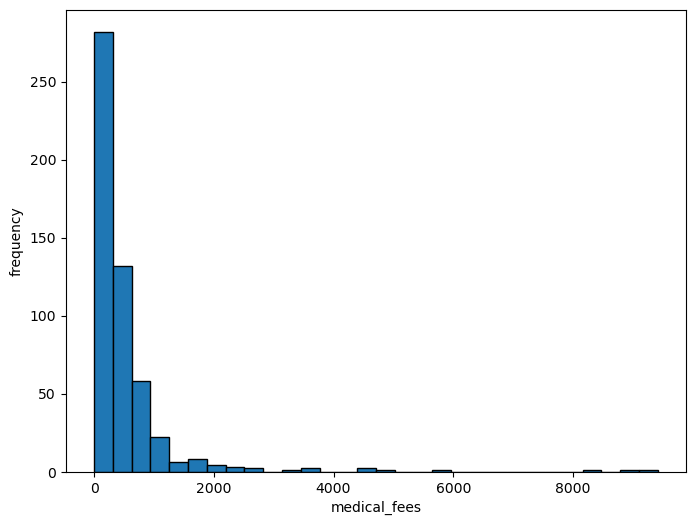

In [23]:
plt.figure(figsize=(8,6))
plt.hist(df['medical_fees'] , bins=30, edgecolor='black')
plt.xlabel('Distribution of Medical Expenses')
plt.xlabel('medical_fees')
plt.ylabel('frequency')
plt.show()

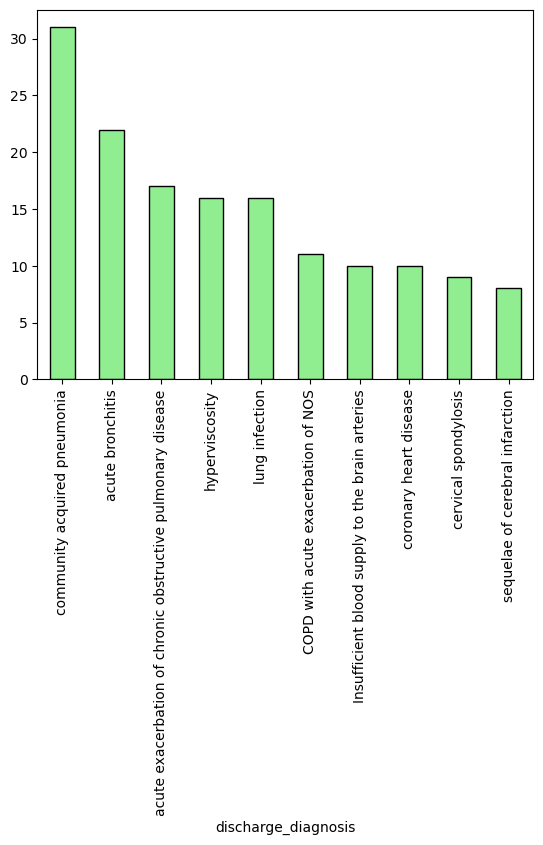

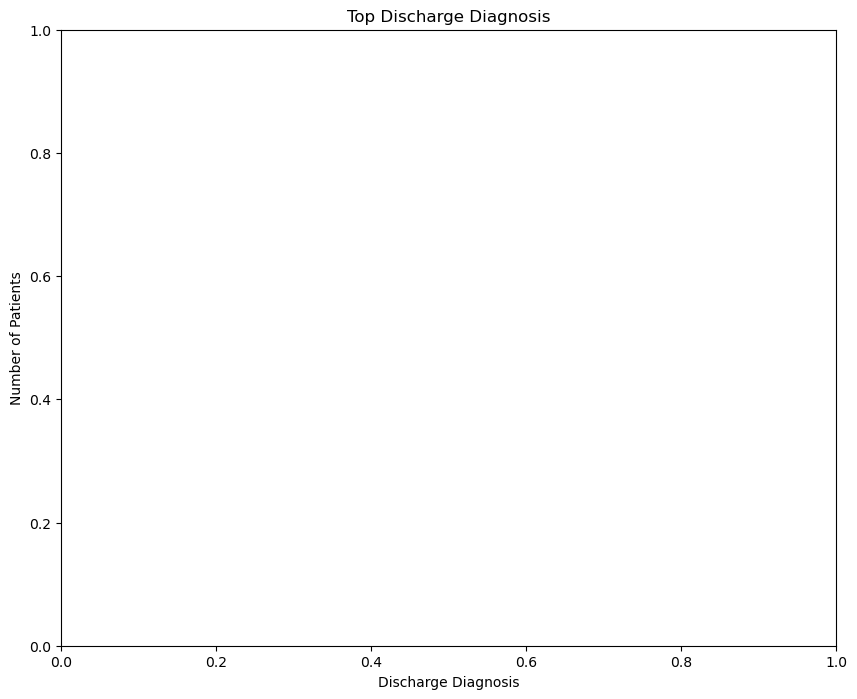

In [24]:
# Ploting bar chart for top diagnosis

import matplotlib.pyplot as plt
top_diagnosis = df['discharge_diagnosis'].value_counts().head(10)
top_diagnosis.plot(kind="bar", color="lightgreen", edgecolor="black")
plt.figure(figsize=(10,8))
plt.title("Top Discharge Diagnosis")
plt.xlabel('Discharge Diagnosis')
plt.ylabel('Number of Patients')
plt.show()

The chart above shows the most frequent discharge diagnosis in the hospital which shows **the community acquired pneumonia** being the highest prevalent diagnosis and other frequent diagnosis include *acute bronchitis* and *chronic obstructive poulmonary disease*. The least diagnosis is the **sequence of cerebral infarction.**

# Aggregation and Grouping
## Here is to group the data into different categories

In [25]:
medical_exp_by_birth = df.groupby('birth_place') ['medical_fees'].agg(
    total_medical_expenses = 'sum',
    avg_medical_expenses = 'mean'
)
print(medical_exp_by_birth)

                                       total_medical_expenses  \
birth_place                                                     
Anshun                                                21050.0   
Anshun City                                           23019.0   
Anshun City Three Taiwan Grain Bureau                   457.0   
Anshun Ninggu Shangyuan                                 351.0   
Anshun, Guizhou                                      148506.7   
...                                                       ...   
Zhejiang                                               3719.5   
Zhenning, Guizhou                                       428.5   
development zone                                        514.0   
local                                                 23240.5   
xishuiguan                                              553.0   

                                       avg_medical_expenses  
birth_place                                                  
Anshun                        

In [26]:
#Grouping the average surgery_fees and bed_fees by department
dept_average_expense = df.groupby('department').agg(
    {'surgery_fees': 'mean', 'bed_fee': 'mean'})
print(dept_average_expense)

                                                    surgery_fees     bed_fee
department                                                                  
 Department of Obstetrics and Gynecology, South...    479.658537   89.265854
 Department of Obstetrics and Gynecology, Weste...    566.939394   72.975758
 Department of Surgery                                482.878788   92.354545
 Emergency Department                                   0.000000   81.411111
 Internal Medicine                                      1.583710   99.186425
 Neck, shoulder, waist and leg pain department        192.000000  229.800000
 Pediatrics                                             0.000000   47.181818
 Second Department of Surgery                         234.666667  120.280000
Department of Obstetrics and Gynecology, Wester...    500.000000   63.600000


In [27]:
# Creating a new column for total spending 
expense_columns = ['fees', 'surgery_fees', 'bed_fee', 'medical_fees', 'inspection_fees',
                     'western_medicine_fees', 'lab_fees', 'grass_fee', 'nursing_fee', 'other_fees', 'anesthesia_fee']

df['total_spending'] = df[expense_columns].sum(axis=1)

In [41]:
# Converting total spending column to 2 decimal places
df['total_spending'] = df['total_spending'].round(2)

In [28]:
# Finding the highest spending by birth place
total_spending_by_birth_place = df.groupby('birth_place') ['total_spending'].sum().sort_values(ascending=False)
print(total_spending_by_birth_place)

birth_place
Anshun, Guizhou                                      1796988.96
Anshun City                                           337759.08
Anshun                                                316579.76
Guizhou                                               226199.36
Guizhou Province                                      152504.90
                                                        ...    
Building 8, No. 4 Tiyu Road, Xixiu District             1935.86
Mulang Village, Bulang Township, Puding County          1882.50
Shuangbao Southeast Breeding Co., Ltd.                  1684.04
Lanqiao Garden, Anshun Development Zone, Guizhou        1654.06
Qingshan Village, Jiaozishan Town, Xixiu District       1585.38
Name: total_spending, Length: 76, dtype: float64


Point: Most of the patient were born in **Anshun, Guizhou**  in terms of spending, which shows the highest spending in the birth place category. 

In [29]:
sum_value = df['total_spending'].sum()
print(f"sum: {sum_value}")
average_value = df['total_spending'].mean()
print(f"Average: {average_value}")

sum: 3313415.54
Average: 6287.316015180266


There is much surprising difference between the sum and average spending which means that there is more patient that are coming to the hospital as a result of such bigger gap between sum and average

In [30]:
department_cost = df.groupby('department')['total_spending'].sum().sort_values(ascending=False)
print(department_cost)

department
 Internal Medicine                                            1379363.46
 Department of Surgery                                         466261.74
 Emergency Department                                          400260.76
 Department of Obstetrics and Gynecology, Western Hospital     315635.18
 Neck, shoulder, waist and leg pain department                 239431.48
 Second Department of Surgery                                  222689.72
 Department of Obstetrics and Gynecology, South Hospital       180437.72
 Pediatrics                                                    103693.34
Department of Obstetrics and Gynecology, Western Hospital        5642.14
Name: total_spending, dtype: float64


Point: Certain department do considerably cost more than others, where internal Medicine dept cost more compare to Pediatrics and Department of Obstetrics and Gynecology, Western Hospital.

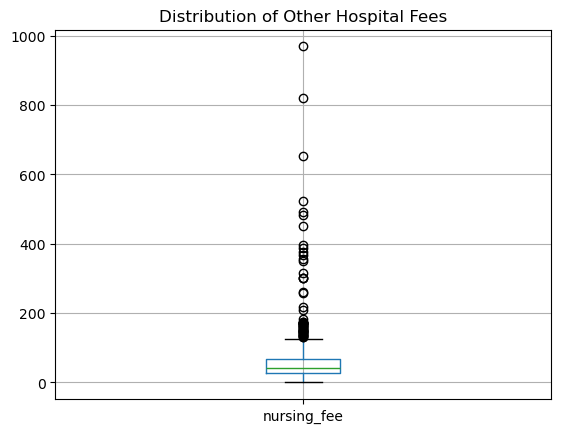

In [31]:
df.boxplot(column='nursing_fee')
plt.title('Distribution of Other Hospital Fees')
plt.show()

In [32]:
#ploting spending against place of birth or region


In [33]:
# Group by region (place_of_birth) and sum expenses

df

,id,department,birth_place,discharge_diagnosis,other_diagnoses_for_discharge,admission_time,discharge_time,fees,outpatient_physician,outpatient_physician_department,...,western_medicine_fees,nursing_fee,grass_fee,anesthesia_fee,other_fees,surgery_fees,bed_fee,medical_fees,days_stayed,total_spending
0,1,"Department of Obstetrics and Gynecology, Weste...",Guizhou,G1P1 LSA cesarean section at 38 weeks gestation,Breech presentation,2016-02-04,2016-02-23,2825.32,Korea,"Department of Obstetrics and Gynecology, West...",...,227.24,108,0.00,406.0,346.48,500,63.6,556.0,19,5642.14
1,2,"Department of Obstetrics and Gynecology, Sout...","Anshun, Guizhou",G4P1 Mid-term induction of labor at 24+6 week...,Mild anemia during pregnancy,2016-02-15,2016-02-19,2163.08,Gu,"Department of Obstetrics and Gynecology, Sout...",...,50.00,42,0.00,15.0,645.68,470,54.4,266.5,4,4325.66
2,3,Internal Medicine,"Anshun, Guizhou",type 2 diabetes,reactive hypoglycemia,2016-01-25,2016-02-17,1649.48,Yin,Internal Medicine,...,339.58,42,0.00,0.0,243.20,0,88.2,171.0,23,3248.96
3,4,"Department of Obstetrics and Gynecology, Sout...",Guizhou,G1P0 induced labor at mid-22nd week of pregnancy,infant deformity,2016-02-17,2016-02-23,1363.52,Zhang Si,"Department of Obstetrics and Gynecology, Sout...",...,40.93,46,0.00,15.0,72.19,470,54.4,94.5,6,2727.04
4,5,"Department of Obstetrics and Gynecology, West...","Anshun, Guizhou",G1P0 50 days pregnant,incomplete abortion,2016-02-05,2016-02-16,1024.74,Korea,"Department of Obstetrics and Gynecology, West...",...,80.49,18,0.00,0.0,38.45,70,31.8,60.0,11,2049.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,523,Department of Surgery,Anshun,left ureteral stone,Left kidney stone and hydrops,2016-01-21,2016-02-04,3244.94,Du,Department of Surgery,...,453.90,50,49.86,0.0,99.58,0,105.6,1155.5,14,6383.38
523,524,Department of Surgery,Anshun,Left upper ureteral stone and left hydronephrosis,Double kidney stones,2016-01-31,2016-02-04,2302.58,high,Department of Surgery,...,239.70,14,0.00,0.0,29.08,0,58.8,560.5,4,4498.66
524,525,Department of Surgery,"Anshun, Guizhou",Left lower ureteral stone and left hydronephrosis,Double kidney stones,2016-01-22,2016-02-04,4330.83,Du,Department of Surgery,...,655.05,54,0.00,0.0,107.58,0,295.2,1818.0,13,8554.66
525,526,Emergency Department,"Anshun, Guizhou",Left lower lung pneumonia,left kidney stone,2016-02-01,2016-02-14,2297.22,Mou,Emergency Department,...,1219.71,22,0.00,0.0,51.01,0,63.0,62.0,13,4593.94


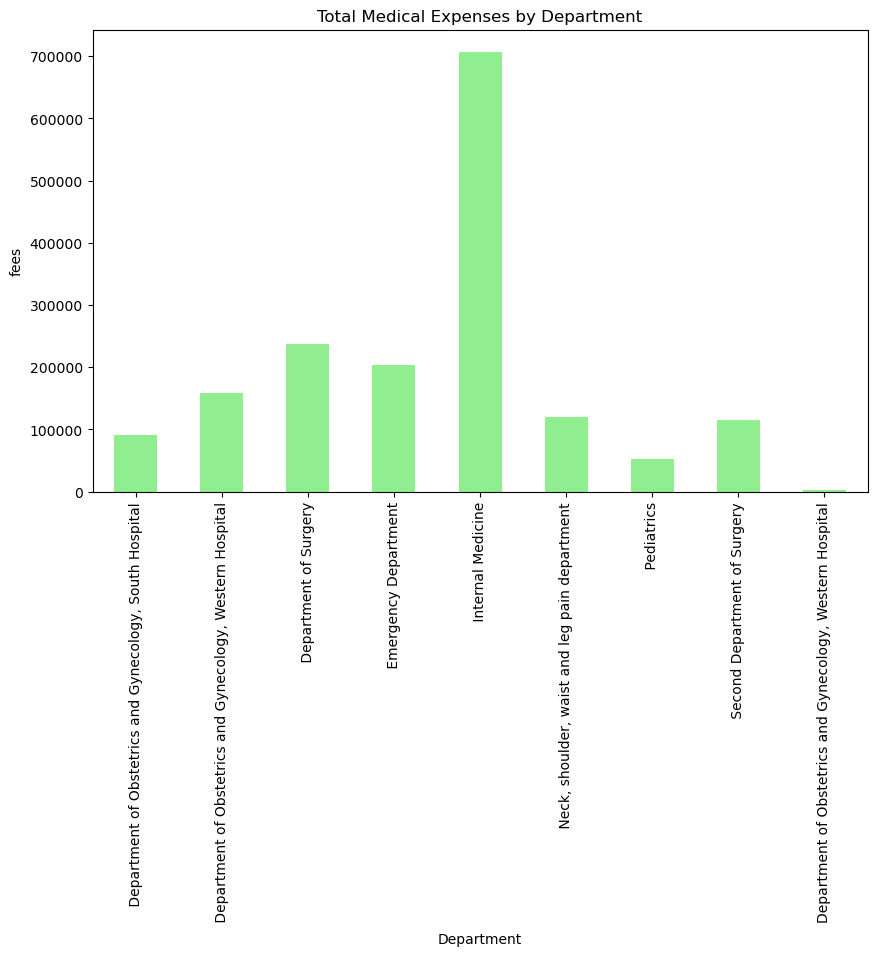

In [34]:
#Plot a bar chart showing the total 'Medical Expenses' for each department.
plt.figure(figsize=(10,6))
df.groupby('department')['fees'].sum().plot(kind='bar', color='lightgreen')
plt.title('Total Medical Expenses by Department')
plt.xlabel('Department')
plt.ylabel('fees')
plt.show()

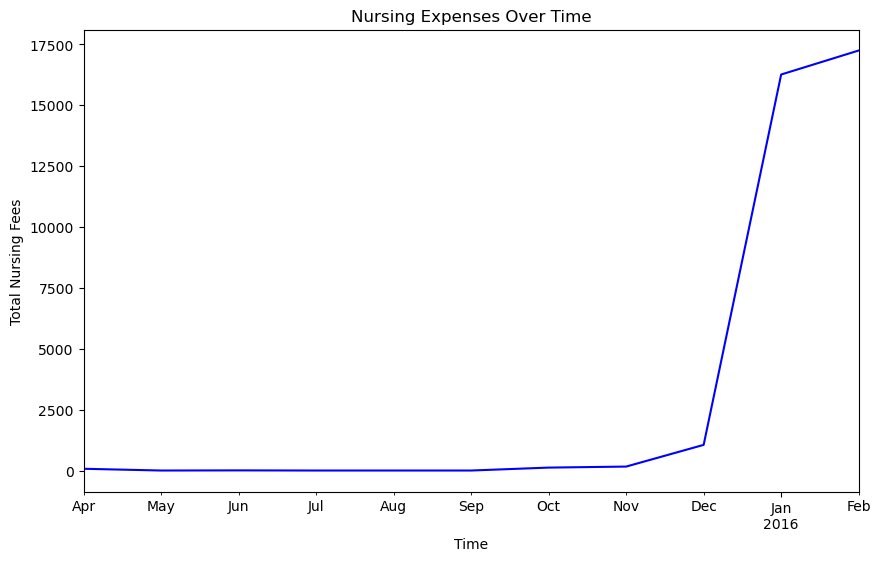

In [35]:
# Showing the trend of nursing fee over time
df.set_index('admission_time').resample('ME')['nursing_fee'].sum().plot(kind='line', figsize=(10,6), color='blue')
plt.title('Nursing Expenses Over Time')
plt.xlabel('Time')
plt.ylabel('Total Nursing Fees')
plt.show()

the chart shows the nursing expenses remained low and stable from April to November, and then sharply increased in December with a continuous rising into January and February. This sudden rise may indicate a seasonal effect as a result of change in hospital operation.

In [36]:
highest_spending = df.groupby('birth_place')['total_spending'].sum().sort_values(ascending=False)
print(highest_spending)

birth_place
Anshun, Guizhou                                      1796988.96
Anshun City                                           337759.08
Anshun                                                316579.76
Guizhou                                               226199.36
Guizhou Province                                      152504.90
                                                        ...    
Building 8, No. 4 Tiyu Road, Xixiu District             1935.86
Mulang Village, Bulang Township, Puding County          1882.50
Shuangbao Southeast Breeding Co., Ltd.                  1684.04
Lanqiao Garden, Anshun Development Zone, Guizhou        1654.06
Qingshan Village, Jiaozishan Town, Xixiu District       1585.38
Name: total_spending, Length: 76, dtype: float64


# Advanced Analysis

In [37]:
import seaborn as sns
print(sns.__version__)

0.13.2


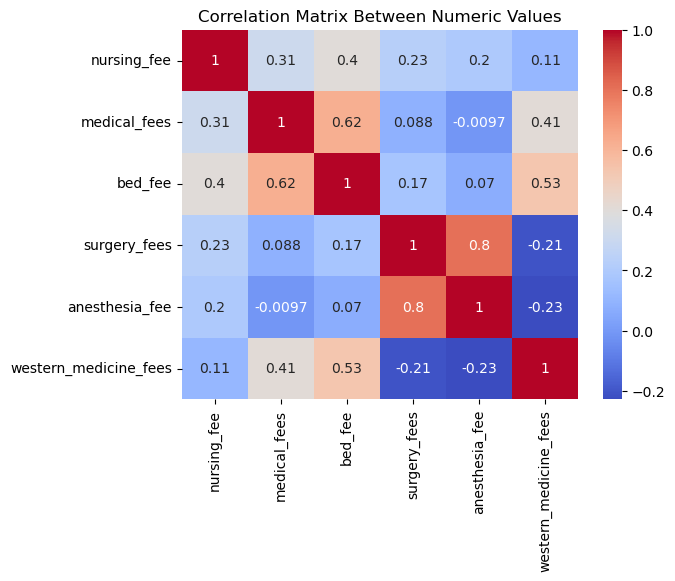

In [38]:
correlation_matrix = df[['nursing_fee', 'medical_fees', 'bed_fee', 'surgery_fees', 'anesthesia_fee', 'western_medicine_fees']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Between Numeric Values')
plt.show()


1. there is a strong positive correlation of 80% between surgery_fees and anesthesia_fee, which makes sense because anesthesia is often required during surgeries, so their costs tend to rise together.

2. medical fee and bed fee show a moderate correlation of 62%, indicating that patient who stay longer and incurred higer bed fees often have higher medical fees due to more or prolonged treatment.

In [39]:
# Predictive Modeling (Simple Linear Regression)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Prepare the data
X = df[['bed_fee', 'surgery_fees', 'nursing_fee']]
y = df['fees']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Model performance
print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_}")

Model Coefficients: [20.99092082  0.95916953  4.06134514]
Model Intercept: 840.6148756222492


In [ ]:
# Exporting the clean dataset 
df.to_csv("C:\\Users\\ME\\Desktop\\Hospital_Project\\clean_dataset.csv", index=False)